# Recipe Ranking Model Comparison

## I. Imports and Global Settings

Cell này khởi tạo toàn bộ thư viện cần thiết cho pipeline học xếp hạng (learning-to-rank) cho bài toán recipe recommendation, đồng thời thiết lập các tham số và cấu hình dùng chung trong toàn bộ hệ thống.

Các cấu hình chính bao gồm:

* `RANDOM_STATE`: đảm bảo tính tái lập (reproducibility) của toàn bộ thí nghiệm, bao gồm chia dữ liệu, huấn luyện mô hình và đánh giá.
* `STOPWORDS`: tập từ dừng dùng để tiền xử lý truy vấn (query), đặc biệt trong tiếng Việt, nhằm loại bỏ các từ không mang nhiều thông tin ngữ nghĩa.
* `FEATURE_COLUMNS`: danh sách các đặc trưng đầu vào (input features) được sử dụng để huấn luyện mô hình xếp hạng.
* `FEATURE_LABELS`: mô tả tương ứng của từng feature, giúp tăng khả năng đọc hiểu và phân tích trong quá trình báo cáo và giải thích mô hình.

In [1]:
from __future__ import annotations

import json
import re
import time
import unicodedata
from collections import defaultdict
from pathlib import Path
from typing import Any, Callable

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.pipeline import Pipeline
from xgboost import XGBRanker

RANDOM_STATE = 42

STOPWORDS = {
    "toi", "muon", "hay", "cho", "biet", "tim", "kiem", "giup", "goi", "y",
    "mot", "mon", "an", "cong", "thuc", "lam", "nau", "chi", "huong", "dan",
    "co", "nao", "khong", "thoi", "gian", "moi", "ngay", "hom", "nay",
    "nhung", "cac", "la", "voi", "cho", "nguoi", "phan",
    "quan", "huyen", "tp", "thanh", "pho",
}

FEATURE_COLUMNS = [
    "ingredient_match_ratio",
    "serving_fit",
    "difficulty_fit",
    "prep_time_fit",
    "cook_time_fit",
    "total_time_fit",
    "prep_time_score",
    "cook_time_score",
    "category_match",
    "dish_name_match",
    "rating_score",
    "view_score",
    "text_match",
]

FEATURE_LABELS = {
    "ingredient_match_ratio": "Ingredient overlap between query and recipe",
    "serving_fit": "How well servings match requested people",
    "difficulty_fit": "Difficulty suitability for the user request",
    "prep_time_fit": "Preparation time suitability for requested time limit",
    "cook_time_fit": "Cooking time suitability for requested time limit",
    "total_time_fit": "Total prep + cook time suitability",
    "prep_time_score": "Global preference score for shorter prep time",
    "cook_time_score": "Global preference score for shorter cook time",
    "category_match": "Category intent overlap between query and recipe",
    "dish_name_match": "Dish name intent overlap between query and recipe",
    "rating_score": "Recipe quality score from popularity",
    "view_score": "Popularity signal from views",
    "text_match": "Text relevance between query and recipe profile",
}


## II. Feature Engineering

### II.1. Load and Merge the Data

Mục tiêu của cell này:
- Dùng dữ liệu recipe từ `dataset/recipes_processed.json` làm nguồn metadata chính.
- Dùng bảng nhãn truy vấn từ `dataset/recipes_dataset.csv`.
- Chuẩn hóa text (`dish_name`) để join nhãn với metadata recipe một cách ổn định.

Sau bước này, mỗi dòng biểu diễn cặp `(query, recipe)` kèm nhãn `label` và thông tin món ăn (nguyên liệu, thời gian, độ khó, độ phổ biến, URL).

In [2]:
def normalize_text(text: Any) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text).replace("Ä", "D").replace("Ä‘", "d")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

QUERY_PHRASE_REPLACEMENTS = {
    "toida": "toi da",
    "khongqua": "khong qua",
    "khauphan": "khau phan",
    "baonhieu": "bao nhieu",
}

QUERY_TOKEN_REPLACEMENTS = {
    "ng": "nguoi",
    "nguo": "nguoi",
    "nguoii": "nguoi",
    "ph": "phut",
    "p": "phut",
    "phu": "phut",
    "phutt": "phut",
    "gioo": "gio",
    "tiengg": "tieng",
    "nhanhh": "nhanh",
    "dee": "de",
    "khoo": "kho",
}

def normalize_query_text(query: Any) -> str:
    q = normalize_text(query)
    if not q:
        return ""

    q = re.sub(r"(\d)([a-z])", r"\1 \2", q)
    q = re.sub(r"([a-z])(\d)", r"\1 \2", q)

    for old, new in QUERY_PHRASE_REPLACEMENTS.items():
        q = re.sub(rf"\b{re.escape(old)}\b", new, q)

    normalized_tokens: list[str] = []
    for token in q.split():
        token = re.sub(r"(.)\1{2,}", r"\1\1", token)
        token = QUERY_TOKEN_REPLACEMENTS.get(token, token)
        for piece in token.split():
            if piece in {"h", "gio", "tieng"}:
                normalized_tokens.append("gio")
            elif piece in {"p", "ph", "phut"}:
                normalized_tokens.append("phut")
            elif piece in {"ng", "nguoi"}:
                normalized_tokens.append("nguoi")
            else:
                normalized_tokens.append(piece)

    deduped_tokens: list[str] = []
    for token in normalized_tokens:
        if not deduped_tokens or deduped_tokens[-1] != token:
            deduped_tokens.append(token)

    return " ".join(deduped_tokens).strip()

def normalize_recipe_id(value: Any) -> str:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    try:
        return str(int(float(text)))
    except Exception:
        return text

def tokenize(text: Any) -> list[str]:
    return [tok for tok in normalize_text(text).split() if tok and tok not in STOPWORDS]

def tokenize_query(text: Any) -> list[str]:
    return [tok for tok in normalize_query_text(text).split() if tok and tok not in STOPWORDS]

def safe_float(value: Any, default: float = 0.0) -> float:
    try:
        if value is None or (isinstance(value, float) and pd.isna(value)):
            return default
        return float(value)
    except Exception:
        return default

def parse_ingredients(value: Any) -> list[dict[str, Any]]:
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

def extract_ingredient_names(value: Any) -> list[str]:
    names: list[str] = []
    for item in parse_ingredients(value):
        if isinstance(item, dict):
            name = normalize_text(item.get("name", ""))
            if name:
                names.append(name)
    return names

def normalize_category(value: Any) -> str:
    if isinstance(value, list):
        return " | ".join(str(item).strip() for item in value if str(item).strip())
    return str(value).strip() if value is not None else ""

def normalize_instructions(value: Any) -> str:
    if isinstance(value, list):
        parts: list[str] = []
        for step in value:
            if isinstance(step, dict):
                title = str(step.get("step_title", "")).strip()
                content = str(step.get("content", "")).strip()
                text = " ".join(part for part in [title, content] if part)
                if text:
                    parts.append(text)
            else:
                raw = str(step).strip()
                if raw:
                    parts.append(raw)
        return " ".join(parts)
    return str(value).strip() if value is not None else ""

def parse_servings_bin(text: Any) -> tuple[float, float]:
    s = normalize_text(text)
    if not s or s == "uncertain":
        return np.nan, np.nan

    range_match = re.search(r"(\d+)\s*-\s*(\d+)\s*nguoi", s)
    if range_match:
        low = float(range_match.group(1))
        high = float(range_match.group(2))
        return low, high

    single_match = re.search(r"(\d+)\s*nguoi", s)
    if single_match:
        value = float(single_match.group(1))
        return value, value

    return np.nan, np.nan

def parse_duration_to_minutes(text: Any) -> float:
    s = normalize_query_text(text)
    if not s:
        return np.nan

    if re.search(r"\bnua\s*(gio|tieng)\b", s):
        return 30.0

    hour_min_match = re.search(r"(\d+(?:\.\d+)?)\s*gio\s*(\d{1,2})?\s*(?:phut)?", s)
    if hour_min_match:
        hour = float(hour_min_match.group(1))
        minute = float(hour_min_match.group(2)) if hour_min_match.group(2) else 0.0
        return hour * 60.0 + minute

    minute_match = re.search(r"(\d+(?:\.\d+)?)\s*phut", s)
    if minute_match:
        return float(minute_match.group(1))

    return np.nan

def extract_requested_people(query: str) -> float:
    query_norm = normalize_query_text(query)

    range_patterns = [
        r"(\d{1,2})\s*-\s*(\d{1,2})\s*(?:nguoi|khau\s*phan|phan|suat)?",
        r"(\d{1,2})\s*(?:den|toi)\s*(\d{1,2})\s*(?:nguoi|khau\s*phan|phan|suat)?",
    ]
    for pattern in range_patterns:
        match = re.search(pattern, query_norm)
        if match:
            low = float(match.group(1))
            high = float(match.group(2))
            return (low + high) / 2.0

    single_patterns = [
        r"(?:cho|an|khau\s*phan|phan\s*an|suat)\s*(\d{1,2})\b",
        r"(\d{1,2})\s*(?:nguoi|khau\s*phan|phan|suat)\b",
    ]
    for pattern in single_patterns:
        match = re.search(pattern, query_norm)
        if match:
            return float(match.group(1))

    return np.nan

def extract_requested_max_minutes(query: str) -> float:
    query_norm = normalize_query_text(query)

    constrained_patterns = [
        r"(?:duoi|toi\s*da|khong\s*qua|it\s*hon|trong)\s*([a-z0-9\s]+)",
        r"(?:<=|<)\s*([a-z0-9\s]+)",
    ]
    for pattern in constrained_patterns:
        match = re.search(pattern, query_norm)
        if not match:
            continue
        tail_text = match.group(1).strip()
        minutes = parse_duration_to_minutes(tail_text)
        if not pd.isna(minutes):
            return float(minutes)
        number_only_match = re.search(r"\b(\d{1,3})\b", tail_text)
        if number_only_match:
            return float(number_only_match.group(1))

    direct_minutes = parse_duration_to_minutes(query_norm)
    if not pd.isna(direct_minutes):
        return float(direct_minutes)

    return np.nan

def popularity_to_rating(popularity: Any) -> float:
    popularity_norm = normalize_text(popularity)
    mapping = {
        "rat thap": 1.0,
        "thap": 2.0,
        "trung binh": 3.0,
        "cao": 4.0,
        "rat cao": 5.0,
        "thinh hanh": 4.5,
    }
    return mapping.get(popularity_norm, 2.5)

def build_recipe_frame(recipes_path: str | Path) -> pd.DataFrame:
    with Path(recipes_path).open("r", encoding="utf-8") as file:
        records = json.load(file)

    recipes_df = pd.DataFrame(records)
    recipes_df["recipe_id"] = [str(i + 1) for i in range(len(recipes_df))]

    if "dish_name" not in recipes_df.columns:
        recipes_df["dish_name"] = ""
    if "category" not in recipes_df.columns:
        recipes_df["category"] = ""
    if "instructions" not in recipes_df.columns:
        recipes_df["instructions"] = ""
    if "ingredients" not in recipes_df.columns:
        recipes_df["ingredients"] = [[] for _ in range(len(recipes_df))]
    if "servings_bin" not in recipes_df.columns:
        recipes_df["servings_bin"] = ""
    if "popularity" not in recipes_df.columns:
        recipes_df["popularity"] = ""
    if "views" not in recipes_df.columns:
        recipes_df["views"] = 0.0
    if "difficulty" not in recipes_df.columns:
        recipes_df["difficulty"] = 0.0
    if "prep_time_min" not in recipes_df.columns:
        recipes_df["prep_time_min"] = 0.0
    if "cook_time_min" not in recipes_df.columns:
        recipes_df["cook_time_min"] = 0.0
    if "url" not in recipes_df.columns:
        recipes_df["url"] = ""

    recipes_df["dish_name"] = recipes_df["dish_name"].fillna("").astype(str)
    recipes_df["category"] = recipes_df["category"].apply(normalize_category)
    recipes_df["instructions"] = recipes_df["instructions"].apply(normalize_instructions)
    recipes_df["ingredients_names"] = recipes_df["ingredients"].apply(extract_ingredient_names)
    recipes_df["views"] = pd.to_numeric(recipes_df["views"], errors="coerce").fillna(0.0)
    recipes_df["difficulty"] = pd.to_numeric(recipes_df["difficulty"], errors="coerce").fillna(0.0)
    recipes_df["prep_time_min"] = pd.to_numeric(recipes_df["prep_time_min"], errors="coerce").fillna(0.0)
    recipes_df["cook_time_min"] = pd.to_numeric(recipes_df["cook_time_min"], errors="coerce").fillna(0.0)
    recipes_df["url"] = recipes_df["url"].fillna("").astype(str)
    recipes_df["dish_name_norm"] = recipes_df["dish_name"].map(normalize_text)

    return recipes_df

def load_merged_recipe_ranking(
    labels_path: str | Path = Path("..") / "dataset" / "recipes_dataset_ver1.csv",
    recipes_path: str | Path = Path("..") / "dataset" / "recipes_processed.json",
) -> pd.DataFrame:
    labels_df = pd.read_csv(labels_path).copy()
    labels_df["dish_name"] = labels_df["dish_name"].fillna("").astype(str)
    labels_df["dish_name_norm"] = labels_df["dish_name"].map(normalize_text)
    labels_df["label"] = pd.to_numeric(labels_df.get("label", 0.0), errors="coerce").fillna(0.0)

    recipes_df = build_recipe_frame(recipes_path)
    query_index = set(labels_df["recipe_id"])
    
    filtered_recipe = recipes_df[recipes_df.index.isin(query_index)]
    
    filtered_recipe.loc[:,['recipe_id']] = filtered_recipe['recipe_id'].astype("int64")
    # The reciped_df have recipe_id start from 1, but the labels_df have recipe_id start from 0, so we need to minus 1 to match them
    filtered_recipe.loc[:,['recipe_id']] =filtered_recipe["recipe_id"].apply(lambda x: x - 1)
    
    merged_df = labels_df.merge(
        filtered_recipe,
        on="recipe_id",
        how="left",
        suffixes=("_label", ""),
    )

    if "dish_name_label" in merged_df.columns:
        merged_df["dish_name"] = merged_df["dish_name"].fillna(merged_df["dish_name_label"])

    return merged_df

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 200)

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
LABELS_PATH = PROJECT_ROOT / "dataset" / "recipes_dataset.csv"
RECIPES_PATH = PROJECT_ROOT / "dataset" / "recipes_processed.json"
SPLIT_URLS_PATH = PROJECT_ROOT / "pre_processing" / "recipe_urls.csv"

raw_df = load_merged_recipe_ranking(LABELS_PATH, RECIPES_PATH)
print(f"Loaded merge shape: {raw_df.shape}")
print(f"Unique queries: {raw_df['query'].nunique()}")
display(raw_df[["query", "dish_name", "category", "url", "servings_bin", "difficulty", "prep_time_min", "cook_time_min", "views", "popularity", "label", "recipe_id"]].head(5))

Loaded merge shape: (7500, 21)
Unique queries: 500


,query,dish_name,category,url,servings_bin,difficulty,prep_time_min,cook_time_min,views,popularity,label,recipe_id
0,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Khô cá hồi làm bằng lò nướng,Món nướng | Ăn vặt,https://www.dienmayxanh.com/vao-bep/2-cach-lam-kho-ca-hoi-moi-la-thom-beo-don-gian-tai-nha-ai-10575,6-8 người,1,10,15,1676,Thấp,3,360
1,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Nướng cá bằng lò vi sóng,Món nướng,https://www.dienmayxanh.com/vao-bep/cach-nuong-ca-bang-lo-vi-song-thom-nuc-mui-ngon-khoi-che-01116,2-3 người,1,45,10,15086,Cao,2,752
2,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Khô cá nục,Món khô - mắm,https://www.dienmayxanh.com/vao-bep/cach-lam-kho-ca-nuc-phoi-nang-sieu-don-gian-va-hap-dan-10770,6-8 người,1,30,360,11649,Cao,0,10114
3,Tôi muốn làm 1 món cá nướng cho 4 người ăn,Cá chỉ vàng nướng,Món nướng,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-chi-vang-nuong-bia-bang-noi-chien-khong-dau-nhanh-22754,2-3 người,1,20,5,787,Thấp,1,111
4,Tôi muốn làm 1 món cá nướng cho 4 người ăn,cá hấp chiên,Món chiên,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-hap-chien-gion-voi-ca-nuc-mon-ngon-quen-lang-dam-23911,2-3 người,2,20,20,1,Rất thấp,0,3398


## II.2. Prepare the Base Feature Frame

Cell này thực hiện bước tiền xử lý dữ liệu đầu vào nhằm chuẩn hóa và xây dựng khung dữ liệu nền phục vụ quá trình feature engineering và huấn luyện mô hình.

Các bước xử lý chính bao gồm:

* Chuẩn hóa kiểu dữ liệu cho các cột số và cột văn bản, đồng thời xử lý các giá trị thiếu hoặc không hợp lệ để đảm bảo tính nhất quán của dataset.
* Tiền xử lý truy vấn người dùng (query), bao gồm:

  * Loại bỏ nhiễu ký tự và chuẩn hóa văn bản.
  * Sửa các lỗi gõ phổ biến.
  * Chuẩn hóa các biểu diễn đơn vị thời gian và khẩu phần ăn về một dạng thống nhất.
* Chuẩn hóa các trường văn bản quan trọng như `query`, `dish_name` và `category` để đảm bảo tính đồng nhất khi so khớp và trích xuất đặc trưng.
* Tạo trường `recipe_text` bằng cách ghép các thông tin mô tả của món ăn (như tên món, nguyên liệu, mô tả), phục vụ cho các phép đo tương đồng văn bản trong các bước feature engineering tiếp theo.
* Trích xuất các thông tin ngữ nghĩa từ query, bao gồm số khẩu phần và số người dùng mong muốn phục vụ.
* Chuẩn hóa và ước lượng khoảng thời gian nấu mong muốn từ query, bao gồm cả các trường hợp không chuẩn hóa rõ ràng (ví dụ: “dưới 30”, “<30 phút”).



In [3]:
def prepare_base_frame(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    numeric_columns = ["prep_time_min", "cook_time_min", "difficulty", "views", "label"]
    for col in numeric_columns:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    text_columns = ["query", "dish_name", "category", "instructions", "servings_bin", "popularity", "url"]
    for col in text_columns:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    if "ingredients_names" not in df.columns:
        df["ingredients_names"] = [[] for _ in range(len(df))]
    df["ingredients_names"] = df["ingredients_names"].apply(
        lambda value: value if isinstance(value, list) else extract_ingredient_names(value)
    )

    if "recipe_id" not in df.columns:
        df["recipe_id"] = np.arange(1, len(df) + 1).astype(str)
    else:
        df["recipe_id"] = df["recipe_id"].map(normalize_recipe_id)

    # Query preprocessing: clean noisy text, fix common typos/abbreviations, and normalize units.
    df["query_raw_norm"] = df["query"].map(normalize_text)
    df["query_norm"] = df["query"].map(normalize_query_text)
    empty_query_mask = df["query_norm"].str.len() == 0
    df.loc[empty_query_mask, "query_norm"] = df.loc[empty_query_mask, "query_raw_norm"]

    df["dish_name_norm"] = df["dish_name"].map(normalize_text)
    df["category_norm"] = df["category"].map(normalize_text)
    df["recipe_text"] = (
        df["dish_name"].fillna("")
        + " | "
        + df["category"].fillna("")
        + " | "
        + df["ingredients_names"].apply(lambda items: " ".join(items))
    )
    df["recipe_text_norm"] = df["recipe_text"].map(normalize_text)

    servings_bounds = df["servings_bin"].apply(parse_servings_bin)
    df[["serving_low", "serving_high"]] = pd.DataFrame(servings_bounds.tolist(), index=df.index)
    df["serving_mid"] = (df["serving_low"] + df["serving_high"]) / 2.0
    df["requested_people"] = df["query_norm"].map(extract_requested_people)
    df["requested_max_minutes"] = df["query_norm"].map(extract_requested_max_minutes)

    return df

## II.3. Feature 1 — Text Match (`text_match`)

Feature này đo lường mức độ tương đồng ngôn ngữ giữa truy vấn người dùng (query) và hồ sơ mô tả của món ăn (recipe profile), nhằm bắt tín hiệu **lexical relevance** trong bài toán learning-to-rank.

### Phương pháp xây dựng:

* Áp dụng mô hình **TF-IDF (Term Frequency–Inverse Document Frequency)** trên trường văn bản đã chuẩn hóa `recipe_text_norm`.
* Biểu diễn truy vấn người dùng trong cùng không gian vector TF-IDF với tập recipe.
* Tính toán **cosine similarity** giữa vector của query và vector của từng recipe tương ứng.

### Ý nghĩa:

* Giá trị gần **1.0**: thể hiện mức độ trùng khớp cao giữa query và mô tả món ăn, tức mức độ liên quan ngữ nghĩa và từ vựng mạnh.
* Giá trị gần **0.0**: thể hiện ít hoặc không có sự trùng khớp về từ khóa hoặc ngữ cảnh giữa query và recipe.

Feature này đóng vai trò như một **baseline lexical matching signal**, giúp mô hình nhận diện các trường hợp match trực tiếp hoặc gần đúng giữa truy vấn và nội dung món ăn.


In [4]:
def add_text_match_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    recipes = df[["recipe_id", "recipe_text_norm"]].drop_duplicates("recipe_id").reset_index(drop=True)
    recipe_index = {recipe_id: idx for idx, recipe_id in enumerate(recipes["recipe_id"])}

    min_df = 2 if len(recipes) >= 2 else 1
    word_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=min_df)
    recipe_word_matrix = word_vectorizer.fit_transform(recipes["recipe_text_norm"])
    query_word_matrix = word_vectorizer.transform(df["query_norm"])
    
    df["text_match"] = [
        float(cosine_similarity(query_word_matrix[idx], recipe_word_matrix[recipe_index[recipe_id]])[0, 0])
        for idx, recipe_id in enumerate(df["recipe_id"])
    ]
    
    return df

## II.4. Features — Ingredient, Serving, Category, Dish Name

Cell này xây dựng nhóm đặc trưng mang tính **intent matching**, nhằm mô hình hóa mức độ phù hợp giữa truy vấn người dùng và đặc trưng cơ bản của món ăn.

Các feature chính bao gồm:

* **`ingredient_match_ratio`**: đo lường mức độ trùng khớp giữa tập token nguyên liệu trong query và danh sách nguyên liệu của recipe. Feature này phản ánh mức độ phù hợp về thành phần món ăn.
* **`serving_fit`**: biểu diễn mức độ tương thích giữa số người dùng mong muốn (extracted từ query) và số khẩu phần của món ăn (`servings_bin`), nhằm đảm bảo tính phù hợp về quy mô phục vụ.
* **`category_match`**: đo mức độ khớp giữa intent truy vấn và phân loại món ăn (category), giúp mô hình nhận diện đúng nhóm món (ví dụ: món chính, món tráng miệng, món nước…).
* **`dish_name_match`**: đánh giá mức độ tương đồng trực tiếp giữa query và tên món ăn (`dish_name`), đóng vai trò như một tín hiệu mạnh cho exact / near-exact match.

Nhóm feature này đóng vai trò quan trọng trong việc giúp mô hình học được **mức độ phù hợp theo ngữ nghĩa và intent người dùng**, bao phủ các khía cạnh từ nguyên liệu, loại món, đến khẩu phần và tên món cụ thể.


In [5]:
def token_overlap_ratio(query_text: Any, target_text: Any) -> float:
    query_tokens = set(tokenize_query(query_text))
    target_tokens = set(tokenize(target_text))
    if not query_tokens or not target_tokens:
        return 0.0
    return float(len(query_tokens.intersection(target_tokens)) / len(query_tokens))

def compute_ingredient_match_ratio(row: pd.Series) -> float:
    query_source = row.get("query_norm", row.get("query", ""))
    query_tokens = set(tokenize_query(query_source))
    if not query_tokens:
        return 0.0

    ingredient_tokens: set[str] = set()
    for name in row.get("ingredients_names", []):
        ingredient_tokens.update(tokenize(name))

    if not ingredient_tokens:
        return 0.0

    overlap = len(query_tokens.intersection(ingredient_tokens))
    return float(overlap / max(len(query_tokens), 1))

def compute_serving_fit(row: pd.Series) -> float:
    requested = row.get("requested_people", np.nan)
    low = row.get("serving_low", np.nan)
    high = row.get("serving_high", np.nan)
    
    if pd.isna(requested) or pd.isna(low) or pd.isna(high):
        return 0.0

    if low <= requested <= high:
        return 1.0

    gap = min(abs(requested - low), abs(requested - high))
    return float(max(0.0, 1.0 - gap / max(requested, 1.0)))

def add_ingredient_and_serving_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    query_series = df["query_norm"] if "query_norm" in df.columns else df["query"]
    df["ingredient_match_ratio"] = df.apply(compute_ingredient_match_ratio, axis=1)
    df["serving_fit"] = df.apply(compute_serving_fit, axis=1)
    df["category_match"] = [
        token_overlap_ratio(query, category)
        for query, category in zip(query_series, df["category"])
    ]
    df["dish_name_match"] = [
        token_overlap_ratio(query, dish_name)
        for query, dish_name in zip(query_series, df["dish_name"])
    ]
    return df

## II.5. Features — Difficulty and Time (EDA-driven)

Cell này xây dựng nhóm đặc trưng dựa trên các **ràng buộc về độ khó và thời gian nấu**, được thiết kế dựa trên phân tích khám phá dữ liệu (Exploratory Data Analysis — EDA). Mục tiêu là mô hình hóa các ràng buộc thực tế của người dùng khi tìm kiếm công thức nấu ăn.

### Các feature chính:

* **`difficulty_fit`**: đo mức độ phù hợp giữa độ khó của món ăn và intent của truy vấn (ví dụ: “dễ làm”, “cho người mới bắt đầu”, “món phức tạp”).
* **`prep_time_fit`, `cook_time_fit`, `total_time_fit`**: đánh giá mức độ phù hợp giữa thời gian chuẩn bị / nấu / tổng thời gian của món ăn với ngưỡng thời gian suy ra từ query (hoặc từ các intent như “nhanh”, “dưới 30 phút”).
* **`prep_time_score`, `cook_time_score`**: các điểm số xếp hạng dựa trên thời gian, ưu tiên các món có thời gian ngắn hơn trong cùng nhóm ứng viên.

### Nhận xét từ EDA:

Phân tích dữ liệu cho thấy các biến thời gian có phân phối **lệch phải mạnh (right-skewed distribution)**, với nhiều món có thời gian nấu dài nhưng chỉ một phần nhỏ người dùng quan tâm đến các món này.

Do đó, thay vì sử dụng các phép biến đổi tuyến tính, các feature về thời gian được thiết kế dưới dạng **rank-based scoring**, giúp:

* Ổn định hóa ảnh hưởng của outlier (các món có thời gian nấu rất lớn),
* Phản ánh tốt hơn hành vi lựa chọn tương đối của người dùng,
* Cải thiện tính phân biệt giữa các món có thời gian gần nhau.


In [6]:
def extract_requested_difficulty(query: Any) -> float:
    query_norm = normalize_query_text(query)
    easy_terms = ["de nau", "don gian", "nhanh", "it buoc", "de lam"]
    hard_terms = ["kho", "phuc tap", "cau ky"]

    if any(term in query_norm for term in easy_terms):
        return 1.0
    if any(term in query_norm for term in hard_terms):
        return 3.0
    return np.nan

def infer_effective_max_minutes(query: Any, requested_max_minutes: float) -> float:
    if not pd.isna(requested_max_minutes) and requested_max_minutes > 0:
        return float(requested_max_minutes)

    query_norm = normalize_query_text(query)
    quick_terms = ["nhanh", "de nau", "it thoi gian", "duoi 30", "30 phut"]
    if any(term in query_norm for term in quick_terms):
        return 30.0
    return np.nan

def compute_difficulty_fit(row: pd.Series) -> float:
    requested = extract_requested_difficulty(row.get("query_norm", row.get("query", "")))
    recipe_difficulty = row.get("difficulty", np.nan)

    if pd.isna(requested) or pd.isna(recipe_difficulty):
        return 0.0

    return float(max(0.0, 1.0 - abs(recipe_difficulty - requested) / 3.0))

def compute_time_fit(time_value: float, requested_max: float) -> float:
    if pd.isna(requested_max) or requested_max <= 0 or pd.isna(time_value) or time_value <= 0:
        return 0.0
    if time_value <= requested_max:
        return 1.0
    overflow = time_value - requested_max
    return float(max(0.0, 1.0 - overflow / requested_max))

def inverse_rank_score(values: pd.Series) -> pd.Series:
    numeric_values = pd.to_numeric(values, errors="coerce").fillna(0.0)
    if len(numeric_values) <= 1:
        return pd.Series(np.ones(len(numeric_values)), index=values.index)
    ranks = numeric_values.rank(method="average", pct=True)
    return (1.0 - ranks).clip(0.0, 1.0)

def add_difficulty_and_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    query_series = df["query_norm"] if "query_norm" in df.columns else df["query"]
    df["difficulty_fit"] = df.apply(compute_difficulty_fit, axis=1)

    df["effective_max_minutes"] = [
        infer_effective_max_minutes(query, requested_max)
        for query, requested_max in zip(query_series, df["requested_max_minutes"])
    ]

    total_time = pd.to_numeric(df["prep_time_min"], errors="coerce").fillna(0.0) + pd.to_numeric(df["cook_time_min"], errors="coerce").fillna(0.0)
    df["total_time_min"] = total_time

    df["prep_time_fit"] = [
        compute_time_fit(prep, max_time)
        for prep, max_time in zip(df["prep_time_min"], df["effective_max_minutes"])
    ]
    df["cook_time_fit"] = [
        compute_time_fit(cook, max_time)
        for cook, max_time in zip(df["cook_time_min"], df["effective_max_minutes"])
    ]
    df["total_time_fit"] = [
        compute_time_fit(total, max_time)
        for total, max_time in zip(df["total_time_min"], df["effective_max_minutes"])
    ]

    # EDA cho thấy prep/cook time lệch phải mạnh, nên dùng rank score thay vì scale tuyến tính.
    df["prep_time_score"] = inverse_rank_score(df["prep_time_min"])
    df["cook_time_score"] = inverse_rank_score(df["cook_time_min"])
    return df

## II.6. Feature 7 — Popularity-derived Rating (`rating_score`)

Feature này khai thác tín hiệu mức độ phổ biến của món ăn, được trích xuất từ trường `popularity` trong file `recipes_processed.json`.

### Cách xây dựng:

* Trường `popularity` ban đầu là một biến phân loại có thứ bậc (ordinal), bao gồm các mức:
  *rất thấp, thấp, trung bình, cao, rất cao, thịnh hành*.
* Các giá trị này được ánh xạ sang thang điểm số tương ứng, đảm bảo tính thứ tự (monotonic ordering).
* Sau đó, toàn bộ giá trị được chuẩn hóa về khoảng **[0, 1]** để đảm bảo tính tương thích với các feature khác trong mô hình.

### Ý nghĩa:

Feature `rating_score` đóng vai trò là một **prior popularity signal**, giúp mô hình:

* Ưu tiên các món ăn phổ biến và được người dùng quan tâm nhiều hơn,
* Bổ sung thông tin ngoài nội dung (content-based signals),
* Cải thiện khả năng xếp hạng trong trường hợp thiếu tín hiệu ngữ nghĩa mạnh từ query.


In [7]:
def add_rating_score_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["rating_score"] = df["popularity"].map(popularity_to_rating) / 5.0
    return df

## II.7. Feature 8 — View Score (`view_score`)

Feature này biểu diễn mức độ phổ biến và mức độ quan tâm thực tế của người dùng đối với mỗi món ăn, được suy ra từ trường `views`.

### Cách xây dựng:

* Giá trị `views` được biến đổi bằng hàm **logarithmic transformation (`log1p`)** nhằm giảm ảnh hưởng của các giá trị ngoại lai (outliers) và làm phẳng phân phối lệch phải.
* Sau đó, giá trị được chuẩn hóa theo giá trị lớn nhất trong tập dữ liệu để đưa về khoảng **[0, 1]**.

### Ý nghĩa:

Feature `view_score` cung cấp một tín hiệu **behavioral popularity**, phản ánh mức độ quan tâm thực tế của người dùng đối với món ăn, thay vì chỉ dựa trên nội dung.



In [8]:
def add_view_score_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    view_signal = np.log1p(pd.to_numeric(df["views"], errors="coerce").fillna(0.0))
    max_signal = float(view_signal.max()) if len(view_signal) else 0.0
    df["view_score"] = view_signal / max_signal if max_signal > 0 else 0.0
    return df

## III. Preparing Data for Training

### Build the Final Feature Table

Hàm `build_recipe_features(...)` thực hiện toàn bộ pipeline feature engineering theo một thứ tự thống nhất và đảm bảo tất cả các cột trong `FEATURE_COLUMNS` đều là dạng số (numeric).

Sau bước này, mỗi dòng dữ liệu vẫn là một cặp `(query, recipe)`, sẵn sàng được đưa vào các mô hình learning-to-rank để huấn luyện và đánh giá.


In [9]:
def build_recipe_features(df: pd.DataFrame) -> pd.DataFrame:
    df = prepare_base_frame(df)
    df = add_text_match_feature(df)
    df = add_ingredient_and_serving_features(df)
    df = add_difficulty_and_time_features(df)
    df = add_rating_score_feature(df)
    df = add_view_score_feature(df)

    for col in FEATURE_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    return df

* Kiểm tra nhanh dữ liệu sau khi xây dựng feature


In [10]:
df = build_recipe_features(raw_df)
print(f"Shape of the feature dataframe: {df.shape}")
print(f"Number of features fed into the model: {len(FEATURE_COLUMNS)}")

feature_explanation_df = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "Explanation": [FEATURE_LABELS[col] for col in FEATURE_COLUMNS],
    }
)
display(feature_explanation_df)

preview_df = (
    df[[
        "query",
        "query_norm",
        "requested_people",
        "requested_max_minutes",
        "dish_name",
        "url",
        "label",
        *FEATURE_COLUMNS,
    ]]
    .head(10)
)
display(preview_df)

Shape of the feature dataframe: (7500, 46)
Number of features fed into the model: 13


,feature,Explanation
0,ingredient_match_ratio,Ingredient overlap between query and recipe
1,serving_fit,How well servings match requested people
2,difficulty_fit,Difficulty suitability for the user request
3,prep_time_fit,Preparation time suitability for requested time limit
4,cook_time_fit,Cooking time suitability for requested time limit
5,total_time_fit,Total prep + cook time suitability
6,prep_time_score,Global preference score for shorter prep time
7,cook_time_score,Global preference score for shorter cook time
8,category_match,Category intent overlap between query and recipe
9,dish_name_match,Dish name intent overlap between query and recipe


,query,query_norm,requested_people,requested_max_minutes,dish_name,url,label,ingredient_match_ratio,serving_fit,difficulty_fit,prep_time_fit,cook_time_fit,total_time_fit,prep_time_score,cook_time_score,category_match,dish_name_match,rating_score,view_score,text_match
0,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Khô cá hồi làm bằng lò nướng,https://www.dienmayxanh.com/vao-bep/2-cach-lam-kho-ca-hoi-moi-la-thom-beo-don-gian-tai-nha-ai-10575,3,0.25,0.50,0.0,0.0,0.0,0.0,0.764933,0.709667,0.25,0.50,0.4,0.530779,0.181974
1,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Nướng cá bằng lò vi sóng,https://www.dienmayxanh.com/vao-bep/cach-nuong-ca-bang-lo-vi-song-thom-nuc-mui-ngon-khoi-che-01116,2,0.25,0.75,0.0,0.0,0.0,0.0,0.093200,0.839400,0.25,0.50,0.8,0.687825,0.108929
2,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Khô cá nục,https://www.dienmayxanh.com/vao-bep/cach-lam-kho-ca-nuc-phoi-nang-sieu-don-gian-va-hap-dan-10770,0,0.25,0.50,0.0,0.0,0.0,0.0,0.209200,0.017133,0.00,0.25,0.8,0.669344,0.050050
3,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Cá chỉ vàng nướng,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-chi-vang-nuong-bia-bang-noi-chien-khong-dau-nhanh-22754,1,0.25,0.75,0.0,0.0,0.0,0.0,0.380733,0.937467,0.25,0.50,0.4,0.476787,0.098453
4,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,cá hấp chiên,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-hap-chien-gion-voi-ca-nuc-mon-ngon-quen-lang-dam-23911,0,0.25,0.75,0.0,0.0,0.0,0.0,0.380733,0.549267,0.00,0.25,0.2,0.049552,0.073502
5,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Mực khô nướng,https://www.dienmayxanh.com/vao-bep/cach-nuong-muc-kho-bang-lo-vi-song-dai-ngon-sieu-nhanh-sieu-15117,1,0.00,0.75,0.0,0.0,0.0,0.0,0.927667,0.972067,0.25,0.25,1.0,0.720007,0.080196
6,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Khô cá bò nướng,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-bo-kho-nuong-thom-lung-chuan-vi-cho-ban-nhau-13446,0,0.25,0.75,0.0,0.0,0.0,0.0,0.556200,0.709667,0.00,0.50,1.0,0.724007,0.073265
7,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Cá thu muối dùi,https://www.dienmayxanh.com/vao-bep/cac-lam-ca-thu-muoi-dui-don-gian-tai-nha-an-toan-ve-sinh-23474,0,0.25,0.50,0.0,0.0,0.0,0.0,0.110133,0.323600,0.00,0.25,0.2,0.325546,0.042550
8,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Cá nướng bơ,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-nuong-bo-ngon-la-de-lam-00493,1,0.25,0.75,0.0,0.0,0.0,0.0,0.209200,0.549267,0.25,0.50,0.4,0.540304,0.355495
9,Tôi muốn làm 1 món cá nướng cho 4 người ăn,toi muon lam 1 mon ca nuong cho 4 nguoi an,4.0,NaN,Cá trích nướng,https://www.dienmayxanh.com/vao-bep/cach-lam-ca-trich-nuong-thom-ngon-mem-ngot-de-lam-tai-nha-09596,4,0.25,1.00,0.0,0.0,0.0,0.0,0.556200,0.323600,0.25,0.50,0.8,0.661175,0.100300


### Shared Train/Validation/Test, Metrics, and Evaluation Helpers

Cell này định nghĩa các thành phần dùng chung cho cả ba mô hình:

* Chia dữ liệu theo `query` thành train/validation/test với tỷ lệ 80/10/10.
* Bộ metric đánh giá xếp hạng gồm `NDCG`, `MRR` và `HIT`.
* Sử dụng `GroupKFold` theo `query` để thực hiện cross-validation.
* Xây dựng các hàm tune và evaluate thống nhất nhằm đảm bảo việc so sánh giữa các mô hình là công bằng và nhất quán.


In [11]:
TRAIN_PERCENT = 0.70
VAL_PERCENT = 0.15
TEST_PERCENT = 0.15
CV_N_SPLITS = 10
CV_TOP_K = 5


def compute_group_metrics(eval_df: pd.DataFrame, score_col: str = "pred_score", top_ks: tuple[int, ...] = (5, 10)) -> dict[str, float]:
    ndcg_store = defaultdict(list)
    mrr_store: list[float] = []
    hit_store = {k: [] for k in top_ks}

    for _, group in eval_df.groupby("query"):
        group = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = group["label"].to_numpy(dtype=float)
        y_score = group[score_col].to_numpy(dtype=float)

        for k in top_ks:
            score = ndcg_score([y_true], [y_score], k=min(k, len(group)))
            ndcg_store[k].append(float(score))

        relevant_positions = np.where(group["label"].to_numpy(dtype=float) >= 3)[0]
        mrr_store.append(float(1.0 / (relevant_positions[0] + 1)) if len(relevant_positions) else 0.0)

        for k in top_ks:
            hit_store[k].append(float((group["label"].head(k) >= 3).any()))

    metrics = {f"NDCG@{k}": float(np.mean(values)) for k, values in ndcg_store.items()}
    metrics["MRR"] = float(np.mean(mrr_store))
    for k in top_ks:
        metrics[f"HIT@{k}"] = float(np.mean(hit_store[k]))
    return metrics


def compute_metrics_by_query(eval_df: pd.DataFrame, score_col: str = "pred_score", top_k: int = CV_TOP_K) -> pd.DataFrame:
    rows = []
    for query, group in eval_df.groupby("query"):
        ranked = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = ranked["label"].to_numpy(dtype=float)
        y_score = ranked[score_col].to_numpy(dtype=float)
        relevant_positions = np.where(y_true >= 3)[0]
        rows.append(
            {
                "query": query,
                "rows": len(ranked),
                f"NDCG@{top_k}": float(ndcg_score([y_true], [y_score], k=min(top_k, len(ranked)))),
                "MRR": float(1.0 / (relevant_positions[0] + 1)) if len(relevant_positions) else 0.0,
                f"HIT@{top_k}": float((ranked["label"].head(top_k) >= 3).any()),
            }
        )
    return pd.DataFrame(rows).sort_values([f"NDCG@{top_k}", "MRR"], ascending=False).reset_index(drop=True)


def build_grouped_train_val_test_split(
    df: pd.DataFrame,
    train_percent: float = TRAIN_PERCENT,
    val_percent: float = VAL_PERCENT,
    test_percent: float = TEST_PERCENT,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if "url" not in df.columns:
        raise ValueError("DataFrame must contain a 'url' column for grouped splitting.")
    if not np.isclose(train_percent + val_percent + test_percent, 1.0):
        raise ValueError("train_percent + val_percent + test_percent must equal 1.0")

    unique_queries = np.array(pd.unique(df["query"]), dtype=object)
    if len(unique_queries) < 3:
        raise ValueError("Need at least 3 unique queries to create train/val/test splits.")

    rng = np.random.default_rng(random_state)
    rng.shuffle(unique_queries)

    n_total = len(unique_queries)
    n_train = max(1, int(np.floor(n_total * train_percent)))
    n_val = max(1, int(np.floor(n_total * val_percent)))
    n_train = min(n_train, n_total - 2)
    n_val = min(n_val, n_total - n_train - 1)
    n_test = n_total - n_train - n_val

    if n_test < 1:
        n_test = 1
        if n_train >= n_val and n_train > 1:
            n_train -= 1
        elif n_val > 1:
            n_val -= 1

    train_queries = set(unique_queries[:n_train])
    val_queries = set(unique_queries[n_train:n_train + n_val])
    test_queries = set(unique_queries[n_train + n_val:])

    train_df = df[df["query"].isin(train_queries)].sort_values(["query", "recipe_id"]).reset_index(drop=True)
    val_df = df[df["query"].isin(val_queries)].sort_values(["query", "recipe_id"]).reset_index(drop=True)
    test_df = df[df["query"].isin(test_queries)].sort_values(["query", "recipe_id"]).reset_index(drop=True)
    return train_df, val_df, test_df


def empty_fit_kwargs(_: pd.DataFrame) -> dict[str, Any]:
    return {}


def group_fit_kwargs(train_df: pd.DataFrame) -> dict[str, Any]:
    return {
        "model__group": train_df.groupby("query").size().tolist(),
    }


def evaluate_candidate(
    estimator,
    train_df: pd.DataFrame,
    feature_columns: list[str],
    cv,
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
) -> pd.DataFrame:
    fold_rows = []
    cv_source_df = train_df.reset_index(drop=True)
    X = cv_source_df[feature_columns]
    y = cv_source_df["label"].to_numpy(dtype=float)
    q_groups = cv_source_df["query"].to_numpy(dtype=object)

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=q_groups), start=1):
        fold_train_df = cv_source_df.iloc[train_idx].sort_values(["query", "recipe_id"]).reset_index(drop=True)
        fold_val_df = cv_source_df.iloc[val_idx].sort_values(["query", "recipe_id"]).reset_index(drop=True)

        fold_estimator = clone(estimator)
        start_time = time.perf_counter()
        fold_estimator.fit(
            fold_train_df[feature_columns],
            fold_train_df["label"],
            **fit_kwargs_builder(fold_train_df),
        )
        fit_time = time.perf_counter() - start_time

        start_time = time.perf_counter()
        y_fold_pred = np.asarray(fold_estimator.predict(fold_val_df[feature_columns]), dtype=float).reshape(-1)
        predict_time = time.perf_counter() - start_time

        fold_eval_df = fold_val_df[["query", "label"]].copy()
        fold_eval_df["pred_score"] = y_fold_pred

        row = {
            "Fold": fold_idx,
            "Fit Time (s)": fit_time,
            "Predict Time (s)": predict_time,
        }
        row.update(compute_group_metrics(fold_eval_df, score_col="pred_score"))
        fold_rows.append(row)

    return pd.DataFrame(fold_rows)


def summarize_cv_results(model_name: str, candidate_id: int, params: dict[str, Any], fold_df: pd.DataFrame) -> dict[str, Any]:
    return {
        "Model": model_name,
        "Candidate": candidate_id,
        "Params": params,
        "CV NDCG@5": fold_df["NDCG@5"].mean(),
        "CV NDCG@10": fold_df["NDCG@10"].mean(),
        "CV MRR": fold_df["MRR"].mean(),
        "CV HIT@5": fold_df["HIT@5"].mean(),
        "CV HIT@10": fold_df["HIT@10"].mean(),
        "CV NDCG@5 Std": fold_df["NDCG@5"].std(ddof=0),
        "CV NDCG@10 Std": fold_df["NDCG@10"].std(ddof=0),
        "CV MRR Std": fold_df["MRR"].std(ddof=0),
        "CV HIT@5 Std": fold_df["HIT@5"].std(ddof=0),
        "CV HIT@10 Std": fold_df["HIT@10"].std(ddof=0),
        "CV Mean Fit Time (s)": fold_df["Fit Time (s)"].mean(),
        "CV Mean Predict Time (s)": fold_df["Predict Time (s)"].mean(),
    }


def tune_model(
    model_name: str,
    estimator,
    param_grid: dict[str, list[Any]],
    train_df: pd.DataFrame,
    feature_columns: list[str],
    cv,
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    primary_metric: str = "NDCG@5",
) -> dict[str, Any]:
    candidate_rows = []
    best_candidate = None
    best_fold_df = None

    for candidate_id, params in enumerate(ParameterGrid(param_grid), start=1):
        configured_estimator = clone(estimator)
        configured_estimator.set_params(**params)

        fold_df = evaluate_candidate(
            configured_estimator,
            train_df,
            feature_columns,
            cv,
            fit_kwargs_builder,
        )
        summary_row = summarize_cv_results(model_name, candidate_id, params, fold_df)
        candidate_rows.append(summary_row)

        if (
            best_candidate is None
            or summary_row[f"CV {primary_metric}"] > best_candidate[f"CV {primary_metric}"]
            or (
                summary_row[f"CV {primary_metric}"] == best_candidate[f"CV {primary_metric}"]
                and summary_row["CV NDCG@10"] > best_candidate["CV NDCG@10"]
            )
        ):
            best_candidate = summary_row
            best_fold_df = fold_df.copy()

    candidates_df = pd.DataFrame(candidate_rows).sort_values(
        by=[f"CV {primary_metric}", "CV NDCG@10", "CV MRR"],
        ascending=False,
    ).reset_index(drop=True)

    return {
        "model_name": model_name,
        "candidates_df": candidates_df,
        "best_candidate": best_candidate,
        "best_fold_df": best_fold_df,
    }


def evaluate_on_test(
    model_name: str,
    estimator,
    best_params: dict[str, Any],
    train_val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_columns: list[str],
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    signal_attr: str | None = None,
) -> tuple[dict[str, Any], dict[str, Any]]:
    final_estimator = clone(estimator)
    final_estimator.set_params(**best_params)

    x_train = train_val_df[feature_columns]
    y_train = train_val_df["label"]
    x_test = test_df[feature_columns]

    start_time = time.perf_counter()
    final_estimator.fit(x_train, y_train, **fit_kwargs_builder(train_val_df))
    train_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    y_test_pred = np.asarray(final_estimator.predict(x_test), dtype=float).reshape(-1)
    test_predict_time = time.perf_counter() - start_time

    test_eval_df = test_df[["query", "label", "recipe_id", "dish_name", *feature_columns]].copy()
    test_eval_df["pred_score"] = y_test_pred

    test_metrics = compute_group_metrics(test_eval_df, score_col="pred_score")
    test_metrics.update({
        "Model": model_name,
        "Train Time (s)": train_time,
        "Test Predict Time (s)": test_predict_time,
        "Best Params": best_params,
    })

    model_step = final_estimator.named_steps["model"]
    artifact = {
        "estimator": final_estimator,
        "eval_df": test_eval_df,
        "signal_values": getattr(model_step, signal_attr, None) if signal_attr else None,
    }
    return test_metrics, artifact


def build_model_summary(cv_result: dict[str, Any], test_metrics: dict[str, Any]) -> dict[str, Any]:
    return {
        "Model": cv_result["model_name"],
        "Best Params": cv_result["best_candidate"]["Params"],
        "CV NDCG@5": cv_result["best_candidate"]["CV NDCG@5"],
        "CV NDCG@10": cv_result["best_candidate"]["CV NDCG@10"],
        "CV MRR": cv_result["best_candidate"]["CV MRR"],
        "CV HIT@5": cv_result["best_candidate"]["CV HIT@5"],
        "CV HIT@10": cv_result["best_candidate"]["CV HIT@10"],
        "CV NDCG@5 Std": cv_result["best_candidate"]["CV NDCG@5 Std"],
        "CV NDCG@10 Std": cv_result["best_candidate"]["CV NDCG@10 Std"],
        "CV MRR Std": cv_result["best_candidate"]["CV MRR Std"],
        "CV HIT@5 Std": cv_result["best_candidate"]["CV HIT@5 Std"],
        "CV HIT@10 Std": cv_result["best_candidate"]["CV HIT@10 Std"],
        "CV Mean Fit Time (s)": cv_result["best_candidate"]["CV Mean Fit Time (s)"],
        "CV Mean Predict Time (s)": cv_result["best_candidate"]["CV Mean Predict Time (s)"],
        "Test NDCG@5": test_metrics["NDCG@5"],
        "Test NDCG@10": test_metrics["NDCG@10"],
        "Test MRR": test_metrics["MRR"],
        "Test HIT@5": test_metrics["HIT@5"],
        "Test HIT@10": test_metrics["HIT@10"],
        "Train Time (s)": test_metrics["Train Time (s)"],
        "Test Predict Time (s)": test_metrics["Test Predict Time (s)"],
    }


def build_signal_frame(signal_values: Any, feature_columns: list[str], signal_kind: str) -> pd.DataFrame:
    if signal_values is None:
        return pd.DataFrame(columns=["feature", "signal_raw", "signal_abs", "signal_norm", "signal_kind"])

    values = np.asarray(signal_values, dtype=float).reshape(-1)
    signal_df = pd.DataFrame(
        {
            "feature": feature_columns,
            "signal_raw": values,
            "signal_abs": np.abs(values),
        }
    )
    total_signal = signal_df["signal_abs"].sum()
    signal_df["signal_norm"] = signal_df["signal_abs"] / total_signal if total_signal else 0.0
    signal_df["signal_kind"] = signal_kind
    return signal_df.sort_values("signal_abs", ascending=False).reset_index(drop=True)


def _split_learning_curve_holdout(df: pd.DataFrame, holdout_frac: float = 0.2, random_state: int = RANDOM_STATE) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique_queries = np.array(pd.unique(df["query"]), dtype=object)
    if len(unique_queries) < 2:
        return df.copy(), df.iloc[0:0].copy()

    rng = np.random.default_rng(random_state)
    rng.shuffle(unique_queries)
    n_holdout = max(1, int(np.floor(len(unique_queries) * holdout_frac)))
    n_holdout = min(n_holdout, len(unique_queries) - 1)
    holdout_queries = set(unique_queries[:n_holdout])
    train_queries = set(unique_queries[n_holdout:])
    return (
        df[df["query"].isin(train_queries)].sort_values(["query", "recipe_id"]).reset_index(drop=True),
        df[df["query"].isin(holdout_queries)].sort_values(["query", "recipe_id"]).reset_index(drop=True),
    )


def _extract_eval_series(
    evals_result: dict[str, Any],
    dataset_candidates: list[str],
    metric_tokens: list[str],
) -> tuple[np.ndarray, str | None]:
    for dataset_name in dataset_candidates:
        if dataset_name not in evals_result:
            continue
        metric_map = evals_result[dataset_name]
        for metric_name, values in metric_map.items():
            metric_name_lower = str(metric_name).lower()
            if any(token in metric_name_lower for token in metric_tokens):
                return np.asarray(values, dtype=float), str(metric_name)
    return np.array([], dtype=float), None


def compute_tree_learning_curve_df(
    estimator,
    data_df: pd.DataFrame,
    feature_columns: list[str],
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
) -> pd.DataFrame:
    curve_train_df, curve_val_df = _split_learning_curve_holdout(data_df)
    if curve_train_df.empty or curve_val_df.empty:
        return pd.DataFrame()

    model = clone(estimator)
    model_step_name = model.named_steps["model"].__class__.__name__.lower()

    fit_kwargs = fit_kwargs_builder(curve_train_df).copy()
    fit_kwargs["model__eval_set"] = [
        (curve_train_df[feature_columns], curve_train_df["label"]),
        (curve_val_df[feature_columns], curve_val_df["label"]),
    ]

    if "xgb" in model_step_name:
        model.set_params(model__eval_metric=["ndcg@5", "rmse"])
        fit_kwargs.pop("model__eval_metric", None)
        loss_tokens = ["rmse", "loss", "error"]
    else:
        fit_kwargs["model__eval_metric"] = ["ndcg@5", "l2"]
        fit_kwargs["model__eval_at"] = [5]
        loss_tokens = ["l2", "loss", "rmse", "error"]

    train_group = curve_train_df.groupby("query").size().tolist()
    val_group = curve_val_df.groupby("query").size().tolist()

    try:
        fit_kwargs["model__eval_group"] = [train_group, val_group]
        model.fit(curve_train_df[feature_columns], curve_train_df["label"], **fit_kwargs)
    except TypeError:
        fit_kwargs.pop("model__eval_group", None)
        model.fit(curve_train_df[feature_columns], curve_train_df["label"], **fit_kwargs)

    model_step = model.named_steps["model"]
    if hasattr(model_step, "evals_result_") and isinstance(model_step.evals_result_, dict):
        evals_result = model_step.evals_result_
    elif hasattr(model_step, "evals_result"):
        evals_result = model_step.evals_result()
    else:
        evals_result = {}

    train_metric, metric_name = _extract_eval_series(
        evals_result,
        dataset_candidates=["training", "validation_0", "valid_0"],
        metric_tokens=["ndcg@5", "ndcg"],
    )
    val_metric, _ = _extract_eval_series(
        evals_result,
        dataset_candidates=["validation_1", "valid_1", "validation_0", "valid_0"],
        metric_tokens=["ndcg@5", "ndcg"],
    )

    train_loss, loss_name = _extract_eval_series(
        evals_result,
        dataset_candidates=["training", "validation_0", "valid_0"],
        metric_tokens=loss_tokens,
    )
    val_loss, _ = _extract_eval_series(
        evals_result,
        dataset_candidates=["validation_1", "valid_1", "validation_0", "valid_0"],
        metric_tokens=loss_tokens,
    )

    if train_metric.size == 0 or val_metric.size == 0:
        train_pred = np.asarray(model.predict(curve_train_df[feature_columns]), dtype=float).reshape(-1)
        val_pred = np.asarray(model.predict(curve_val_df[feature_columns]), dtype=float).reshape(-1)

        train_eval_df = curve_train_df[["query", "label"]].copy()
        train_eval_df["pred_score"] = train_pred
        val_eval_df = curve_val_df[["query", "label"]].copy()
        val_eval_df["pred_score"] = val_pred

        return pd.DataFrame(
            [
                {
                    "epoch": 1,
                    "train_metric": compute_group_metrics(train_eval_df, top_ks=(5,))["NDCG@5"],
                    "val_metric": compute_group_metrics(val_eval_df, top_ks=(5,))["NDCG@5"],
                    "train_loss": np.nan,
                    "val_loss": np.nan,
                    "metric_name": "NDCG@5",
                    "loss_name": "loss",
                }
            ]
        )

    n_steps = min(len(train_metric), len(val_metric))
    if n_steps == 0:
        return pd.DataFrame()

    if train_loss.size == 0 or val_loss.size == 0:
        train_loss = np.full(n_steps, np.nan)
        val_loss = np.full(n_steps, np.nan)
    else:
        n_loss = min(len(train_loss), len(val_loss), n_steps)
        n_steps = min(n_steps, n_loss)

    rows = []
    for idx in range(n_steps):
        rows.append(
            {
                "epoch": idx + 1,
                "train_metric": float(train_metric[idx]),
                "val_metric": float(val_metric[idx]),
                "train_loss": float(train_loss[idx]) if not np.isnan(train_loss[idx]) else np.nan,
                "val_loss": float(val_loss[idx]) if not np.isnan(val_loss[idx]) else np.nan,
                "metric_name": metric_name or "NDCG@5",
                "loss_name": loss_name or "loss",
            }
        )
    return pd.DataFrame(rows)


def compute_alpha_curve_df(
    estimator,
    data_df: pd.DataFrame,
    feature_columns: list[str],
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    alpha_values: list[Any],
) -> pd.DataFrame:
    rows = []
    curve_train_df, curve_val_df = _split_learning_curve_holdout(data_df)

    for alpha in alpha_values:
        if curve_train_df.empty or curve_val_df.empty:
            continue

        model = clone(estimator)
        model.set_params(model__alpha=alpha)
        model.fit(curve_train_df[feature_columns], curve_train_df["label"], **fit_kwargs_builder(curve_train_df))

        train_pred = np.asarray(model.predict(curve_train_df[feature_columns]), dtype=float).reshape(-1)
        val_pred = np.asarray(model.predict(curve_val_df[feature_columns]), dtype=float).reshape(-1)

        train_eval_df = curve_train_df[["query", "label"]].copy()
        train_eval_df["pred_score"] = train_pred
        val_eval_df = curve_val_df[["query", "label"]].copy()
        val_eval_df["pred_score"] = val_pred

        rows.append(
            {
                "alpha": float(alpha),
                "train_NDCG@5": compute_group_metrics(train_eval_df, top_ks=(5,))["NDCG@5"],
                "val_NDCG@5": compute_group_metrics(val_eval_df, top_ks=(5,))["NDCG@5"],
            }
        )

    return pd.DataFrame(rows).sort_values("alpha").reset_index(drop=True)


def register_model_run(
    run_key: str,
    model_name: str,
    estimator,
    param_grid: dict[str, list[Any]],
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    signal_attr: str | None,
    signal_kind: str,
    curve_kind: str,
) -> dict[str, Any]:
    train_val_df = pd.concat([train_df, val_df], ignore_index=True)

    cv_result = tune_model(
        model_name=model_name,
        estimator=estimator,
        param_grid=param_grid,
        train_df=train_df,
        feature_columns=FEATURE_COLUMNS,
        cv=cv_strategy,
        fit_kwargs_builder=fit_kwargs_builder,
        primary_metric="NDCG@5",
    )
    test_metrics, artifact = evaluate_on_test(
        model_name=model_name,
        estimator=estimator,
        best_params=cv_result["best_candidate"]["Params"],
        train_val_df=train_val_df,
        test_df=test_df,
        feature_columns=FEATURE_COLUMNS,
        fit_kwargs_builder=fit_kwargs_builder,
        signal_attr=signal_attr,
    )
    summary = build_model_summary(cv_result, test_metrics)
    signal_df = build_signal_frame(artifact["signal_values"], FEATURE_COLUMNS, signal_kind)
    signal_df["Model"] = model_name
    per_query_df = compute_metrics_by_query(artifact["eval_df"], top_k=CV_TOP_K)
    per_query_df["Model"] = model_name

    best_estimator = clone(estimator)
    best_estimator.set_params(**cv_result["best_candidate"]["Params"])
    if curve_kind == "tree":
        learning_curve_df = compute_tree_learning_curve_df(
            estimator=best_estimator,
            data_df=train_val_df,
            feature_columns=FEATURE_COLUMNS,
            fit_kwargs_builder=fit_kwargs_builder,
        )
    elif curve_kind == "alpha":
        alpha_values = list(param_grid.get("model__alpha", []))
        learning_curve_df = compute_alpha_curve_df(
            estimator=best_estimator,
            data_df=train_val_df,
            feature_columns=FEATURE_COLUMNS,
            fit_kwargs_builder=fit_kwargs_builder,
            alpha_values=alpha_values,
        )
    else:
        learning_curve_df = pd.DataFrame()

    run = {
        "model_name": model_name,
        "cv_result": cv_result,
        "artifact": artifact,
        "summary": summary,
        "signal_df": signal_df,
        "per_query_df": per_query_df,
        "learning_curve_df": learning_curve_df,
        "curve_kind": curve_kind,
    }
    model_runs[run_key] = run
    display(pd.DataFrame(cv_result["best_candidate"]["Params"], index=["Value"]).T)
    display(pd.DataFrame([summary]))
    return run


train_df, val_df, test_df = build_grouped_train_val_test_split(
    df,
    train_percent=TRAIN_PERCENT,
    val_percent=VAL_PERCENT,
    test_percent=TEST_PERCENT,
    random_state=RANDOM_STATE,
)
print(f"train/val/test lines: {len(train_df)} / {len(val_df)} / {len(test_df)}")
print(f"train/val/test urls: {train_df['url'].nunique()} / {val_df['url'].nunique()} / {test_df['url'].nunique()}")
print(f"train/val/test queries: {train_df['query'].nunique()} / {val_df['query'].nunique()} / {test_df['query'].nunique()}")

n_splits = min(CV_N_SPLITS, train_df["query"].nunique())
if n_splits < 2:
    raise ValueError("Not enough unique queries for the specified number of cross-validation splits.")

cv_strategy = GroupKFold(n_splits=n_splits)
print(f"Using {n_splits}-fold GroupKFold for cross-validation.")

model_runs: dict[str, dict[str, Any]] = {}

train/val/test lines: 5250 / 1125 / 1125
train/val/test urls: 1672 / 712 / 712
train/val/test queries: 350 / 75 / 75
Using 10-fold GroupKFold for cross-validation.


## IV. Train and Compare Models

### IV.1. Model 1 - LightGBM Ranker

Cell này khởi tạo `LightGBMRanker`, định nghĩa grid tham số và thực hiện tuning/evaluation trên cùng một pipeline.

Lưu ý:

* Sử dụng `fit_kwargs_builder=group_fit_kwargs` vì bài toán learning-to-rank cần thông tin kích thước group theo query.
* `signal_attr="feature_importances_"` để trích xuất độ quan trọng của feature phục vụ phân tích so sánh giữa các mô hình.


In [12]:
lgbm_pipeline = Pipeline(
    [
        (
            "model",
            lgb.LGBMRanker(
                objective="rank_xendcg",
                learning_rate=0.05,
                min_child_samples=70,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        )
    ]
)

LGBM_PARAM_GRID = {
    "model__n_estimators": [50, 70, 100, 150],
    "model__max_depth": [4, 5, 6],
    "model__num_leaves": [5, 10, 15, 20, 30],
    "model__max_bin": [31, 63, 127],
}

lightgbm_run = register_model_run(
    run_key="lightgbm",
    model_name="LightGBM Ranker",
    estimator=lgbm_pipeline,
    param_grid=LGBM_PARAM_GRID,
    fit_kwargs_builder=group_fit_kwargs,
    signal_attr="feature_importances_",
    signal_kind="importance",
    curve_kind="tree",
)

,Value
model__max_bin,31
model__max_depth,4
model__n_estimators,150
model__num_leaves,10


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,LightGBM Ranker,"{'model__max_bin': 31, 'model__max_depth': 4, 'model__n_estimators': 150, 'model__num_leaves': 10}",0.798137,0.847306,0.722818,0.805714,0.822857,0.039599,0.037396,0.077593,0.064902,0.070912,0.054177,0.003532,0.784864,0.828421,0.622768,0.706667,0.733333,0.084508,0.004033


### IV.2. Model 2 - Ridge Ranker

Cell này huấn luyện `Ridge` như một baseline tuyến tính và thực hiện tìm kiếm tham số `alpha` bằng cùng quy trình cross-validation.

Ưu điểm:

* Huấn luyện nhanh.
* Dễ diễn giải nhờ các hệ số tuyến tính.

Nhược điểm:

* Chỉ mô hình hóa quan hệ tuyến tính giữa feature và điểm relevance.


In [13]:
ridge_pipeline = Pipeline(
    [
        (
            "model",
            Ridge(random_state=RANDOM_STATE),
        )
    ]
)

RIDGE_PARAM_GRID = {
    "model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

ridge_run = register_model_run(
    run_key="ridge",
    model_name="Ridge Ranker",
    estimator=ridge_pipeline,
    param_grid=RIDGE_PARAM_GRID,
    fit_kwargs_builder=empty_fit_kwargs,
    signal_attr="coef_",
    signal_kind="coefficient",
    curve_kind="alpha",
)

,Value
model__alpha,10.0


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,Ridge Ranker,{'model__alpha': 10.0},0.769018,0.823458,0.686822,0.794286,0.811429,0.033532,0.034091,0.081942,0.066148,0.073623,0.003018,0.001408,0.768136,0.819063,0.613375,0.693333,0.733333,0.002189,0.000858


### IV.3. Model 3 - XGBoost Ranker

Cell này khởi tạo `XGBRanker`, thực hiện grid search và đánh giá theo cùng một protocol.

Lưu ý:

* Sử dụng objective pairwise cho bài toán ranking.
* Cần group theo query khi huấn luyện (fit).
* Sử dụng `feature_importances_` để so sánh mức độ ảnh hưởng của các feature giữa các mô hình.


In [14]:
xgb_pipeline = Pipeline(
    [
        (
            "model",
            XGBRanker(
                objective="rank:pairwise",
                eval_metric=["ndcg@5", "ndcg@10"],
                learning_rate=0.05,
                subsample=0.85,
                colsample_bytree=1.0,
                reg_alpha=0.0,
                reg_lambda=1.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0,
                gamma=0.1,
            ),
        )
    ]
)

XGB_PARAM_GRID = {
    "model__n_estimators": [30, 50, 70, 100, 150],
    "model__max_depth": [3, 4, 5],
    "model__min_child_weight": [1, 2, 3, 5],
}

xgboost_run = register_model_run(
    run_key="xgboost",
    model_name="XGBoost Ranker",
    estimator=xgb_pipeline,
    param_grid=XGB_PARAM_GRID,
    fit_kwargs_builder=group_fit_kwargs,
    signal_attr="feature_importances_",
    signal_kind="importance",
    curve_kind="tree",
)

,Value
model__max_depth,3
model__min_child_weight,1
model__n_estimators,150


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,XGBoost Ranker,"{'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 150}",0.802337,0.848225,0.717293,0.8,0.822857,0.034279,0.04059,0.085879,0.072281,0.070912,0.182185,0.005216,0.798704,0.846605,0.631111,0.72,0.746667,0.213479,0.00454


### Learning Curves

Với LightGBM và XGBoost: đường learning curve được vẽ theo từng epoch/boosting iteration trên tập train và validation, bao gồm hai đường thể hiện metric (NDCG@5) và loss.

Với Ridge: learning curve được biểu diễn theo giá trị `alpha` để thể hiện mức độ ảnh hưởng của regularization đến hiệu năng mô hình.

Sau khi hiển thị biểu đồ, notebook sẽ tự động in nhận xét về xu hướng hội tụ, mức độ dao động và dấu hiệu overfitting dựa trên đường validation.


,epoch,train_metric,val_metric,train_loss,val_loss,metric_name,loss_name,alpha,train_NDCG@5,val_NDCG@5
0,1.0,0.693221,0.652352,3.828255,3.624522,ndcg@5,l2,NaN,NaN,NaN
1,2.0,0.718279,0.679709,3.796669,3.601013,ndcg@5,l2,NaN,NaN,NaN
2,3.0,0.722975,0.687177,3.769196,3.582166,ndcg@5,l2,NaN,NaN,NaN
3,4.0,0.751447,0.719301,3.744336,3.570646,ndcg@5,l2,NaN,NaN,NaN
4,5.0,0.755490,0.725761,3.722409,3.555830,ndcg@5,l2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
303,146.0,0.866062,0.780358,1.924592,2.017031,ndcg@5,rmse,NaN,NaN,NaN
304,147.0,0.865833,0.780767,1.925633,2.018251,ndcg@5,rmse,NaN,NaN,NaN
305,148.0,0.865480,0.780767,1.926102,2.019746,ndcg@5,rmse,NaN,NaN,NaN
306,149.0,0.866312,0.781787,1.926807,2.021144,ndcg@5,rmse,NaN,NaN,NaN


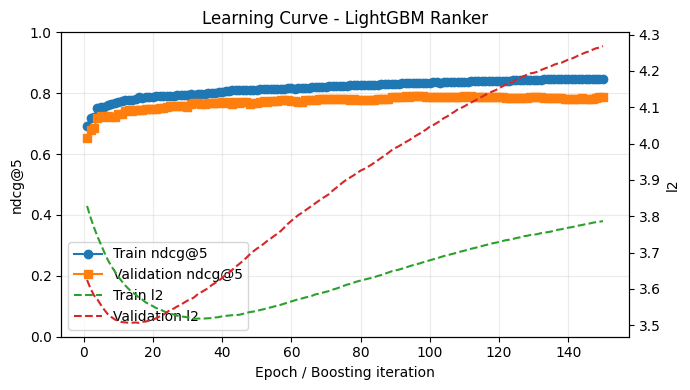

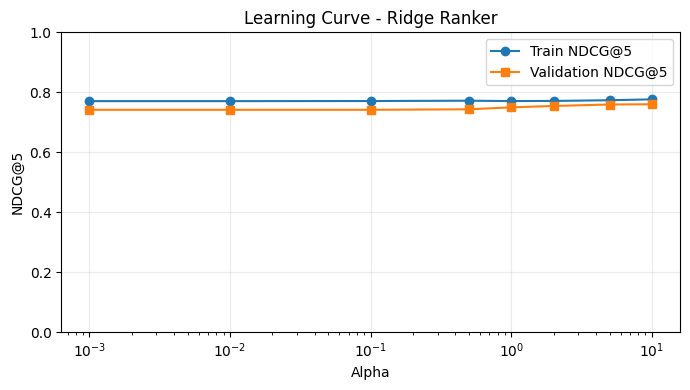

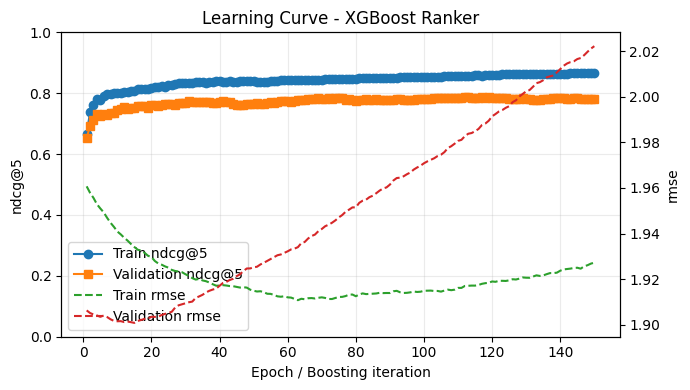

Nhận xét learning curves:
- LightGBM Ranker: có xu hướng hội tụ tốt; dao động nhẹ; chưa thấy overfitting rõ ràng.
- Ridge Ranker: đạt val NDCG@5 cao nhất tại alpha=10.
- XGBoost Ranker: có xu hướng hội tụ tốt; dao động nhẹ; có dấu hiệu overfitting.


In [15]:
learning_curve_frames = [
    run["learning_curve_df"]
    for run in model_runs.values()
    if "learning_curve_df" in run and not run["learning_curve_df"].empty
]

if not learning_curve_frames:
    print("Không có dữ liệu learning curve. Hãy chạy lại các cell huấn luyện mô hình.")
else:
    learning_curve_compare_df = pd.concat(learning_curve_frames, ignore_index=True)
    display(learning_curve_compare_df)

    for run in model_runs.values():
        fig, ax = plt.subplots(1, 1, figsize=(7, 4))

        curve_df = run["learning_curve_df"]
        if curve_df.empty:
            plt.close(fig)
            continue

        model_name = run["model_name"]
        curve_kind = run.get("curve_kind", "tree")

        if curve_kind == "tree" and "epoch" in curve_df.columns:
            x = curve_df["epoch"].to_numpy(dtype=float)
            train_metric = curve_df["train_metric"].to_numpy(dtype=float)
            val_metric = curve_df["val_metric"].to_numpy(dtype=float)

            metric_name = str(curve_df.get("metric_name", pd.Series(["metric"])).iloc[0])
            loss_name = str(curve_df.get("loss_name", pd.Series(["loss"])).iloc[0])

            line_train_metric = ax.plot(x, train_metric, color="#1f77b4", marker="o", label=f"Train {metric_name}")[0]
            line_val_metric = ax.plot(x, val_metric, color="#ff7f0e", marker="s", label=f"Validation {metric_name}")[0]

            ax.set_xlabel("Epoch / Boosting iteration")
            ax.set_ylabel(metric_name)
            ax.set_ylim(0.0, 1.0)
            ax.grid(alpha=0.25)

            handles = [line_train_metric, line_val_metric]
            labels = [line_train_metric.get_label(), line_val_metric.get_label()]

            has_loss = (
                "train_loss" in curve_df.columns
                and "val_loss" in curve_df.columns
                and not (curve_df["train_loss"].isna().all() or curve_df["val_loss"].isna().all())
            )

            if has_loss:
                ax2 = ax.twinx()
                train_loss = curve_df["train_loss"].to_numpy(dtype=float)
                val_loss = curve_df["val_loss"].to_numpy(dtype=float)

                line_train_loss = ax2.plot(x, train_loss, color="#2ca02c", linestyle="--", label=f"Train {loss_name}")[0]
                line_val_loss = ax2.plot(x, val_loss, color="#d62728", linestyle="--", label=f"Validation {loss_name}")[0]

                ax2.set_ylabel(loss_name)
                handles.extend([line_train_loss, line_val_loss])
                labels.extend([line_train_loss.get_label(), line_val_loss.get_label()])

            ax.legend(handles, labels, loc="best")

        else:
            x = curve_df["alpha"].to_numpy(dtype=float)
            train_y = curve_df["train_NDCG@5"].to_numpy(dtype=float)
            val_y = curve_df["val_NDCG@5"].to_numpy(dtype=float)

            ax.semilogx(x, train_y, marker="o", label="Train NDCG@5")
            ax.semilogx(x, val_y, marker="s", label="Validation NDCG@5")

            ax.set_xlabel("Alpha")
            ax.set_ylabel("NDCG@5")
            ax.set_ylim(0.0, 1.0)
            ax.grid(alpha=0.25)
            ax.legend(loc="best")

        ax.set_title(f"Learning Curve - {model_name}")
        plt.tight_layout()
        plt.show()

    print("Nhận xét learning curves:")

    for run in model_runs.values():
        curve_df = run.get("learning_curve_df", pd.DataFrame())
        if curve_df.empty:
            continue

        model_name = run["model_name"]
        curve_kind = run.get("curve_kind", "tree")

        if curve_kind == "tree" and "epoch" in curve_df.columns and len(curve_df) >= 2:
            val_metric = curve_df["val_metric"].to_numpy(dtype=float)
            train_metric = curve_df["train_metric"].to_numpy(dtype=float)

            gain = float(val_metric[-1] - val_metric[0])
            recent = val_metric[-min(5, len(val_metric)):]
            recent_std = float(np.std(recent))
            gap = float(train_metric[-1] - val_metric[-1])

            if gain > 0.01:
                converge_note = "có xu hướng hội tụ tốt"
            elif gain >= -0.01:
                converge_note = "gần như dừng cải thiện (plateau)"
            else:
                converge_note = "chưa hội tụ tốt"

            if recent_std < 0.01:
                oscillation_note = "dao động nhẹ"
            elif recent_std < 0.03:
                oscillation_note = "dao động vừa"
            else:
                oscillation_note = "dao động mạnh"

            overfit_note = (
                "có dấu hiệu overfitting" if gap > 0.08 else "chưa thấy overfitting rõ ràng"
            )

            print(f"- {model_name}: {converge_note}; {oscillation_note}; {overfit_note}.")

        elif curve_kind == "alpha":
            best_row = curve_df.loc[curve_df["val_NDCG@5"].idxmax()]
            print(
                f"- {model_name}: đạt val NDCG@5 cao nhất tại alpha={best_row['alpha']:.4g}."
            )

## V. Models analysis


Cell này tổng hợp kết quả của tất cả mô hình và sắp xếp theo các chỉ số trên tập test chính:

* `Test NDCG@5`
* `Test NDCG@10`
* `Test MRR`

Bảng kết quả giúp so sánh trực tiếp chất lượng giữa các mô hình trong cùng một pipeline đánh giá.


In [16]:
comparison_summary_df = (
    pd.DataFrame([run["summary"] for run in model_runs.values()])
    .sort_values(["Test NDCG@5", "Test NDCG@10", "Test MRR"], ascending=False)
    .reset_index(drop=True)
)
display(comparison_summary_df)

,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,XGBoost Ranker,"{'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 150}",0.802337,0.848225,0.717293,0.800000,0.822857,0.034279,0.040590,0.085879,0.072281,0.070912,0.182185,0.005216,0.798704,0.846605,0.631111,0.720000,0.746667,0.213479,0.004540
1,LightGBM Ranker,"{'model__max_bin': 31, 'model__max_depth': 4, 'model__n_estimators': 150, 'model__num_leaves': 10}",0.798137,0.847306,0.722818,0.805714,0.822857,0.039599,0.037396,0.077593,0.064902,0.070912,0.054177,0.003532,0.784864,0.828421,0.622768,0.706667,0.733333,0.084508,0.004033
2,Ridge Ranker,{'model__alpha': 10.0},0.769018,0.823458,0.686822,0.794286,0.811429,0.033532,0.034091,0.081942,0.066148,0.073623,0.003018,0.001408,0.768136,0.819063,0.613375,0.693333,0.733333,0.002189,0.000858


## Accuracy vs Computational Cost

Phần này trực quan hóa sự đánh đổi giữa hiệu quả xếp hạng và chi phí tính toán:

* Biểu đồ bên trái: các metric trên tập test.
* Biểu đồ bên phải: thời gian huấn luyện và suy luận.

Mục tiêu là lựa chọn mô hình không chỉ có chất lượng tốt mà còn phù hợp về chi phí triển khai trong thực tế.


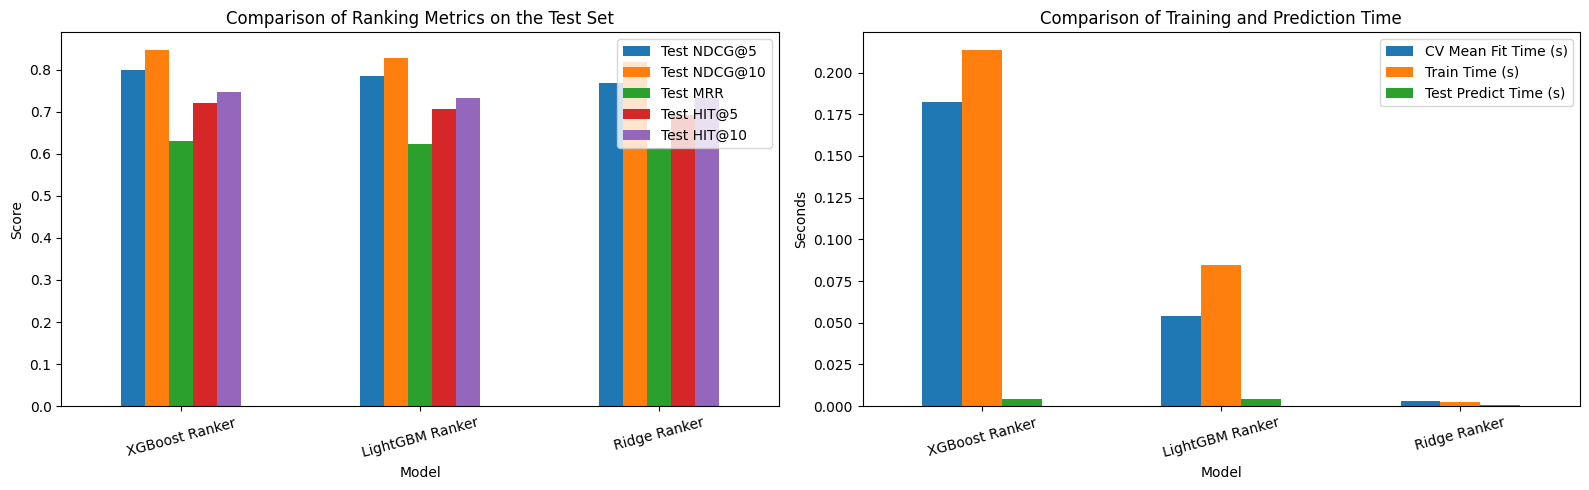

In [17]:
metric_cols = ["Test NDCG@5", "Test NDCG@10", "Test MRR", "Test HIT@5", "Test HIT@10"]
timing_cols = ["CV Mean Fit Time (s)", "Train Time (s)", "Test Predict Time (s)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
comparison_summary_df.set_index("Model")[metric_cols].plot(kind="bar", ax=axes[0])
axes[0].set_title("Comparison of Ranking Metrics on the Test Set")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=15)

comparison_summary_df.set_index("Model")[timing_cols].plot(kind="bar", ax=axes[1])
axes[1].set_title("Comparison of Training and Prediction Time")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


Kết quả thường cho thấy ba mô hình có chất lượng xếp hạng khá sát nhau trên cùng bộ feature recipe. Mô hình tuyến tính (Ridge) thường có lợi thế về tốc độ huấn luyện và suy luận, trong khi LightGBM và XGBoost linh hoạt hơn trong việc học các tương tác phi tuyến giữa các feature.

Vì vậy, việc lựa chọn mô hình cuối cùng nên được cân nhắc dựa trên ba yếu tố chính:

* Chất lượng metric (NDCG/MRR/HIT),
* Chi phí huấn luyện và suy luận,
* Mức độ dễ giải thích khi triển khai thực tế.


### Comparing Feature Signals Across Models

Trong notebook này, `signal` là tên gọi chung cho mức độ ảnh hưởng của từng feature trong các mô hình.

Cụ thể:

* Với LightGBM và XGBoost: `signal` được hiểu là **feature importance** do mô hình học được trong quá trình huấn luyện.
* Với Ridge Regression: `signal` tương ứng với độ lớn của hệ số (`coef_`) của từng feature.

Để đảm bảo tính so sánh công bằng giữa các mô hình, tất cả giá trị signal được lấy giá trị tuyệt đối và chuẩn hóa về thang **`signal_norm`**.

Do đó, khi đọc biểu đồ, cần hiểu theo nghĩa **tương đối giữa các feature**, thay vì so sánh trực tiếp giá trị gốc vốn phụ thuộc vào từng loại mô hình khác nhau.


Model,LightGBM Ranker,Ridge Ranker,XGBoost Ranker
feature_label,,,
Recipe quality score from popularity,0.025279,0.013155,0.030835
Difficulty suitability for the user request,0.022305,0.030335,0.049303
Global preference score for shorter cook time,0.055762,0.012077,0.045590
Total prep + cook time suitability,0.060967,0.045746,0.050646
Cooking time suitability for requested time limit,0.006691,0.004235,0.066882
Popularity signal from views,0.068401,0.024933,0.055336
Preparation time suitability for requested time limit,0.015613,0.005913,0.072655
Global preference score for shorter prep time,0.094424,0.040715,0.064822
Ingredient overlap between query and recipe,0.109294,0.070236,0.084061


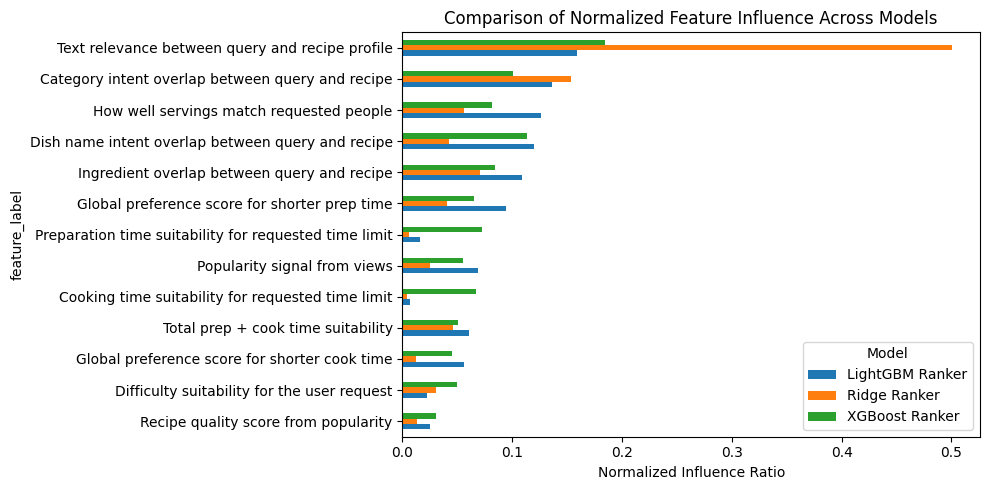

In [18]:
signal_compare_df = pd.concat([run["signal_df"] for run in model_runs.values()], ignore_index=True)
signal_compare_df["feature_label"] = signal_compare_df["feature"].map(FEATURE_LABELS)
signal_pivot_df = (
    signal_compare_df
    .pivot(index="feature_label", columns="Model", values="signal_norm")
    .fillna(0.0)
)
signal_pivot_df = signal_pivot_df.loc[signal_pivot_df.max(axis=1).sort_values(ascending=True).index]
display(signal_pivot_df)

plt.figure(figsize=(10, 5))
signal_pivot_df.plot(kind="barh", ax=plt.gca())
plt.title("Comparison of Normalized Feature Influence Across Models")
plt.xlabel("Normalized Influence Ratio")
plt.tight_layout()
plt.show()



Biểu đồ cho thấy mỗi mô hình sử dụng các nhóm feature theo cách khác nhau, mặc dù cùng trên một tập dữ liệu.

Các xu hướng thường gặp:

* `text_match` và `ingredient_match_ratio` thường là hai tín hiệu mạnh nhất vì bám sát trực tiếp vào ý định truy vấn của người dùng.
* `serving_fit` đặc biệt hữu ích khi truy vấn có thông tin rõ ràng về số người dùng hoặc khẩu phần ăn.
* `difficulty_fit`, `prep_time_fit`, `cook_time_fit` phát huy hiệu quả trong các truy vấn có ràng buộc cụ thể như “dễ nấu”, “nhanh”, hoặc giới hạn thời gian.
* `rating_score` và `view_score` đóng vai trò là các tín hiệu về độ phổ biến và chất lượng, giúp mô hình cải thiện khả năng xếp hạng tổng thể.

Từ đó có thể định hướng cải thiện mô hình bằng cách mở rộng bộ parser cho query tiếng Việt và bổ sung thêm các đặc trưng ngữ nghĩa sâu hơn nhằm tăng khả năng hiểu ý định người dùng.


---

## Conclusion

Notebook đã được xây dựng đồng bộ trên bộ dữ liệu recipe:

* Metadata của món ăn được lấy từ file `dataset/recipes_processed.json`.
* Tập dữ liệu được chia train/test theo URL trong `pre_processing/recipe_urls.csv` với tỷ lệ 8:2.
* Toàn bộ feature và phần mô tả (markdown) đã được chuyển đổi sang ngữ cảnh bài toán recommendation cho món ăn.


